# Generación, limpieza y transformación de un DataSet el principio GIGO

Fecha: 28 de mayo del 2026

Autor: Fernando Lezama Garcia

# Objetivo general
identificar problemas de calidad de datos,aplicar técnicas de limpieza y transformación,
y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning mediante el principio GIGO.

# Actividad

Identifique y documente:

- Valores nulos
- Outliers (Negativos o fuera de rango)
- Datos inválidos
- Facturas canceladas ( identificadas con la letra c)
- Duplicados
- Problemas de formato o tipo de datos (Fechas o Monto)

Posteriormente:

- Limpie el dataset
- Transforme los datos
- Justifique las decisiones tomadas
- Explique cómo afecta el principio GIGO al análisis de datos y Machine Learning

# Graficas solicitadas para la identificación de anomalias
1. Ventas por pais
2. Heatmap de valores nulos
3. Distribución del monto

# Nota: 
Al terminar exportar el dataset limpio a formato csv y subir junto con el Laboratorio a GitHub, cumpliendo  con la siguiente estructura.

    - Notebooks (Folder)
        - Lab07.ipynb
    - DataSet (Folder)
        - Data_Limpio_Factura.csv

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
import numpy as np

In [25]:
# Cargar el dataset sucio
df = pd.read_csv("ventas-por-factura.csv")

In [9]:
df.head(5)

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [26]:
df.tail()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,"-12,70"
25949,553060,5/13/2021 10:44:00,15826.0,United Kingdom,488,"720,00"
25950,577049,11/17/2021 13:58:00,17397.0,United Kingdom,104,"298,78"
25951,550122,4/14/2021 12:39:00,12931.0,United Kingdom,1176,"1488,00"
25952,537999,12/9/2020 11:44:00,NaN,United Kingdom,-223,"0,00"


In [10]:
# Detectar si existen filas exactamente iguales
df.duplicated().sum()

np.int64(10)

In [11]:
# Porcentaje de valores nulos por columna
(df.isnull().sum() / len(df)) * 100

N° de factura        0.000000
Fecha de factura     0.000000
ID Cliente          14.349016
País                 0.000000
Cantidad             0.000000
Monto                0.000000
dtype: float64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     25953 non-null  object 
 1   Fecha de factura  25953 non-null  object 
 2   ID Cliente        22229 non-null  float64
 3   País              25953 non-null  object 
 4   Cantidad          25953 non-null  int64  
 5   Monto             25953 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.2+ MB


In [14]:
# Verificar tipos de datos. Notarás que 'Monto' es tipo 'object' (texto) debido a las comas.
df.dtypes

N° de factura        object
Fecha de factura     object
ID Cliente          float64
País                 object
Cantidad              int64
Monto                object
dtype: object

In [15]:
# Resumen estadístico de 'Cantidad' para observar valores atípicos (negativos)
df['Cantidad'].describe()

count    25953.000000
mean       199.474049
std       1107.075809
min     -80995.000000
25%          6.000000
50%        100.000000
75%        240.000000
max      80995.000000
Name: Cantidad, dtype: float64

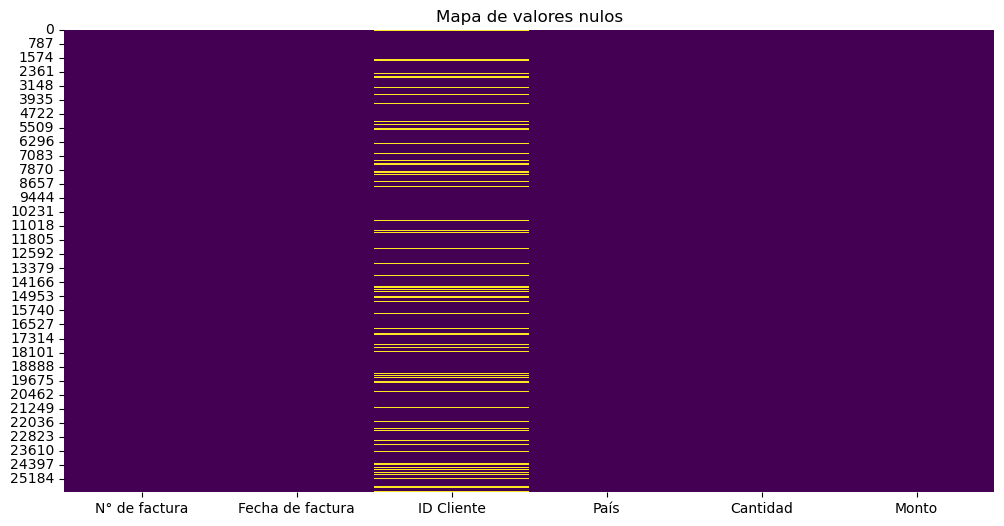

In [17]:
#Mapa de calor de valores nulos
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Mapa de valores nulos")
plt.show()

In [18]:
# Reemplazamos la coma por punto para poder convertir 'Monto' a numérico
df['Monto_Num'] = df['Monto'].astype(str).str.replace(',', '.').astype(float)
df['Monto_Num'].describe()

count     25953.000000
mean        375.657552
std        2009.042459
min     -168469.600000
25%          11.550000
50%         207.050000
75%         408.660000
max      168469.600000
Name: Monto_Num, dtype: float64

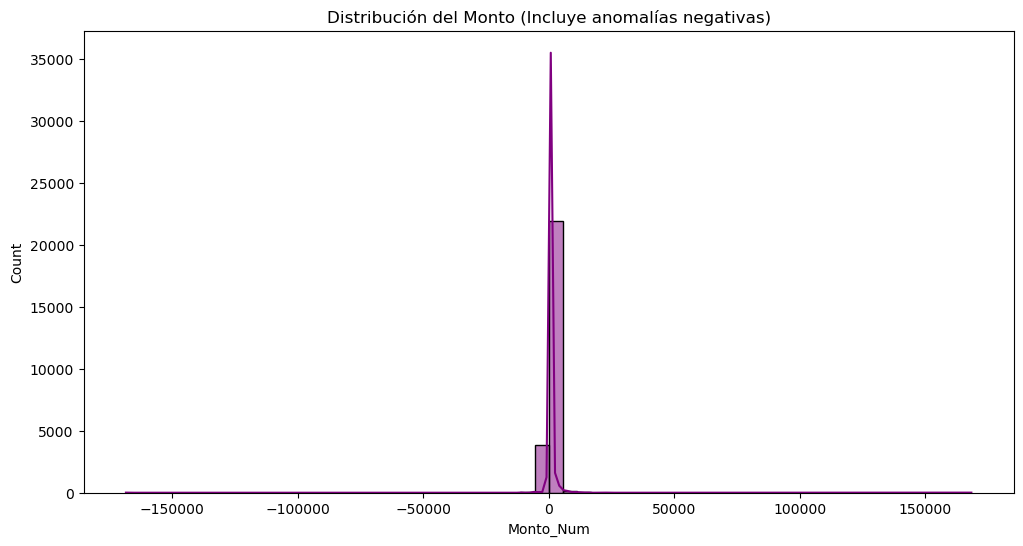

In [19]:
#Distribución del monto
plt.figure(figsize=(12, 6))
sns.histplot(df['Monto_Num'], bins=60, kde=True, color='purple')
plt.title('Distribución del Monto (Incluye anomalías negativas)')
plt.show()

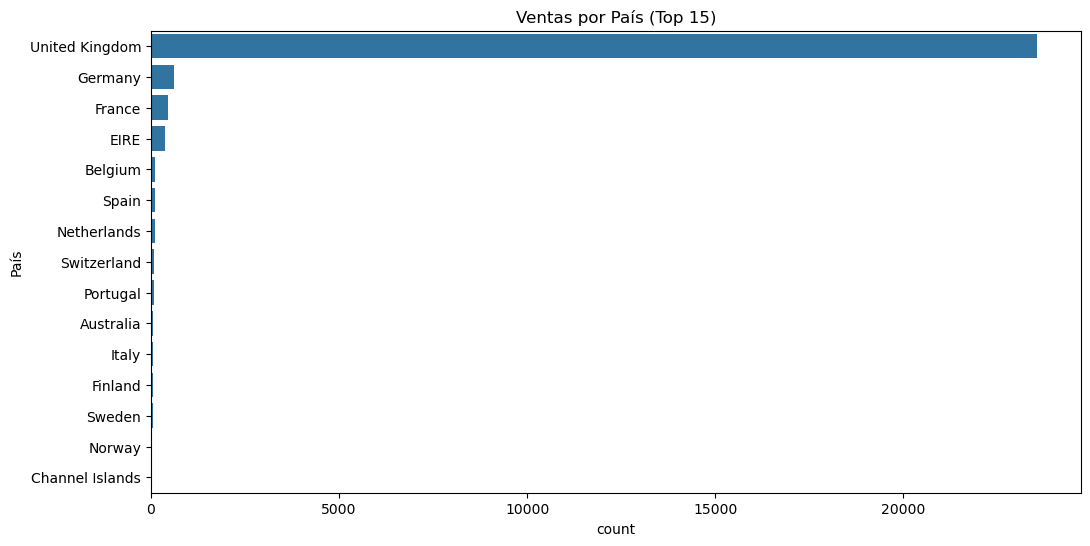

In [21]:
#Mapeado de ventas por país
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='País', order=df['País'].value_counts().index[:15])
plt.title('Ventas por País (Top 15)')
plt.show()

In [22]:
# Borrando datos duplicados
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [23]:
# Aplicar el cambio a la columna original 'Monto' y convertir fechas
df['Monto'] = df['Monto'].astype(str).str.replace(',', '.').astype(float)
df['Fecha de factura'] = pd.to_datetime(df['Fecha de factura'])

In [24]:
# Borramos la columna temporal que usamos para la gráfica
df.drop(columns=['Monto_Num'], inplace=True)
df.dtypes

N° de factura               object
Fecha de factura    datetime64[ns]
ID Cliente                 float64
País                        object
Cantidad                     int64
Monto                      float64
dtype: object

In [27]:
#Vamos a clasificar el id como 0 para especificar la venta anonima o venta de mostrador
df["ID Cliente"] = df["ID Cliente"].fillna(0)

In [30]:
#Transformar 'Monto' a numérico PRIMERO (reemplazar coma por punto)
df['Monto'] = df['Monto'].astype(str).str.replace(',', '.').astype(float)

In [32]:
#Tratamiento de Cantidades y Montos negativos (Los volvemos NaN)
df.loc[df["Cantidad"] < 0, "Cantidad"] = np.nan
df.loc[df["Monto"] < 0, "Monto"] = np.nan

In [34]:
#Calculamos las medianas correspondientes
mediana_cantidad = df["Cantidad"].median()
mediana_monto = df["Monto"].median()

In [35]:
#Rellenamos los espacios vacíos con la mediana para no alterar drásticamente la distribución
df["Cantidad"] = df["Cantidad"].fillna(mediana_cantidad)
df["Monto"] = df["Monto"].fillna(mediana_monto)

In [36]:
# Verificamos que el tamaño del DataFrame se mantiene intacto
df.shape

(25953, 6)

# Justificación de las decisiones de limpieza

1. Duplicados: Se eliminaron las filas repetidas para no sesgar el análisis contando ventas por partida doble.
2. Valores Nulos: Se eliminaron los registros que no tenían ID Cliente. Un registro de venta sin cliente pierde trazabilidad y no sirve para hacer segmentaciones o perfiles de consumo.
3. Problemas de Formato: El Monto usaba comas para decimales, por lo que Python lo leía como texto. Se reemplazaron por puntos y se convirtió a flotante (float). Las fechas se transformaron a datetime para posibilitar agrupaciones por tiempo.
4. Outliers (Negativos): Existían cantidades y montos menores a cero (facturas canceladas o devoluciones). Se decidió filtrar el dataset para que solo queden valores positivos, centrando el análisis únicamente en ingresos y compras efectivas.

# Principio GIGO (Garbage In, Garbage Out)

El principio GIGO dicta que la calidad de los resultados de cualquier sistema depende enteramente de la calidad de los datos que ingresan a él. 

Si este dataset se hubiera utilizado en un algoritmo de Machine Learning sin ser limpiado:
* Los modelos de predicción intentarían sumar ventas que en realidad fueron devoluciones (valores negativos), alterando los ingresos reales.
* Los algoritmos fallarían al intentar procesar operaciones matemáticas sobre la columna Monto porque estaba catalogada como texto debido a las comas.
* Los registros duplicados y sin ID Cliente generarían falsos perfiles o ruido en el análisis.
Por lo tanto, los datos basura de entrada siempre resultarán en conclusiones falsas y modelos inútiles a la salida.